
# ● NAME - Aayush Soam
# ● GHG Emission Prediction Project 
# ● AICTE/ SHELL EDUNET FOUNDATION INTERN

This notebook covers data cleaning, EDA, and machine learning modeling for greenhouse gas (GHG) emission prediction.

# Import Required Libraries
Import pandas, matplotlib, seaborn, numpy, scikit-learn modules, os, and joblib.

In [1]:
# Step 1: Libraries
%pip install pandas matplotlib seaborn scikit-learn joblib openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: C:\Users\thaku\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Load and Clean Excel Data
Load data from multiple Excel sheets for different years, clean column names, and concatenate into a single DataFrame.

In [13]:
# Step 2: Load and Clean Excel Data
excel_file = 'SupplyChainEmissionFactorsforUSIndustriesCommodities.xlsx'
years = range(2010, 2017)
all_data = []

for year in years:
    print(f" Processing year: {year}")
    try:
        df_com = pd.read_excel(excel_file, sheet_name=f'{year}_Detail_Commodity')
        df_ind = pd.read_excel(excel_file, sheet_name=f'{year}_Detail_Industry')

        df_com['Source'] = 'Commodity'
        df_ind['Source'] = 'Industry'
        df_com['Year'] = df_ind['Year'] = year

        df_com.columns = df_com.columns.str.strip()
        df_ind.columns = df_ind.columns.str.strip()

        df_com.rename(columns={'Commodity Code': 'Code', 'Commodity Name': 'Name'}, inplace=True)
        df_ind.rename(columns={'Industry Code': 'Code', 'Industry Name': 'Name'}, inplace=True)

        print(f" Year {year} Loaded: Commodity={df_com.shape}, Industry={df_ind.shape}")
        all_data.append(pd.concat([df_com, df_ind], ignore_index=True))

    except Exception as e:
        print(f" Error in {year}: {e}")

if all_data:
    df = pd.concat(all_data, ignore_index=True)
    print(f"\n Final dataset shape: {df.shape}")
    print(df.head())
else:
    print(" No data was loaded. Please check the Excel file and sheet names.")

 Processing year: 2010
 Year 2010 Loaded: Commodity=(1576, 15), Industry=(1580, 15)
 Processing year: 2011
 Year 2011 Loaded: Commodity=(1576, 15), Industry=(1580, 15)
 Processing year: 2012
 Year 2012 Loaded: Commodity=(1576, 15), Industry=(1580, 15)
 Processing year: 2013
 Year 2013 Loaded: Commodity=(1576, 15), Industry=(1580, 15)
 Processing year: 2014
 Year 2014 Loaded: Commodity=(1576, 15), Industry=(1580, 15)
 Processing year: 2015
 Year 2015 Loaded: Commodity=(1576, 15), Industry=(1580, 15)
 Processing year: 2016
 Year 2016 Loaded: Commodity=(1576, 15), Industry=(1580, 15)

 Final dataset shape: (22092, 15)
     Code                                               Name       Substance  \
0  1111A0  Fresh soybeans, canola, flaxseeds, and other o...  carbon dioxide   
1  1111A0  Fresh soybeans, canola, flaxseeds, and other o...         methane   
2  1111A0  Fresh soybeans, canola, flaxseeds, and other o...   nitrous oxide   
3  1111A0  Fresh soybeans, canola, flaxseeds, and other o

# Remove Unnamed Columns
Check for and remove any 'Unnamed: 7' columns from the DataFrame.

In [14]:
# Remove unnamed column if exists
if 'df' in locals() and 'Unnamed: 7' in df.columns:
    df.drop(columns=['Unnamed: 7'], inplace=True)
else:
    print(" DataFrame 'df' is not defined. Please load your data first.")

# Save Cleaned Data
Save the cleaned DataFrame to a CSV file for further processing.

In [15]:
# Save cleaned data
if 'df' in locals():
	df.to_csv("cleaned_ghg_data.csv", index=False)
	print(" Cleaned data saved as 'cleaned_ghg_data.csv'")
else:
	print(" DataFrame 'df' is not defined. Please load and clean your data first.")

 Cleaned data saved as 'cleaned_ghg_data.csv'


# Data Preprocessing
Reload the cleaned CSV, ensure necessary folders exist, and prepare the DataFrame for modeling.

In [16]:
# Step 3: Data Preprocessing and Modeling
# Ensure folders
os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Load cleaned data
df = pd.read_csv("cleaned_ghg_data.csv")

# Remove extra column if exists
if 'Unnamed: 7' in df.columns:
    df.drop(columns=['Unnamed: 7'], inplace=True)

# Encode Categorical Columns
Map categorical columns ('Substance', 'Unit', 'Source') to numerical values.

In [17]:
# Encode categorical columns
df['Substance'] = df['Substance'].map({'carbon dioxide': 0, 'methane': 1, 'nitrous oxide': 2, 'other GHGs': 3})
df['Unit'] = df['Unit'].map({'kg/2018 USD, purchaser price': 0, 'kg CO2e/2018 USD, purchaser price': 1})
df['Source'] = df['Source'].map({'Commodity': 0, 'Industry': 1})

# Exploratory Data Analysis (EDA)
Display dataset info, null values, summary statistics, plot target distribution, top emitters, countplots, and correlation heatmap.


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 14 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Code                                                    22092 non-null  object 
 1   Name                                                    22092 non-null  object 
 2   Substance                                               22092 non-null  int64  
 3   Unit                                                    22092 non-null  int64  
 4   Supply Chain Emission Factors without Margins           22092 non-null  float64
 5   Margins of Supply Chain Emission Factors                22092 non-null  float64
 6   Supply Chain Emission Factors with Margins              22092 non-null  float64
 7   DQ ReliabilityScore of Factors without Margins          22092 non-null  int64  
 8   DQ TemporalCorrelati

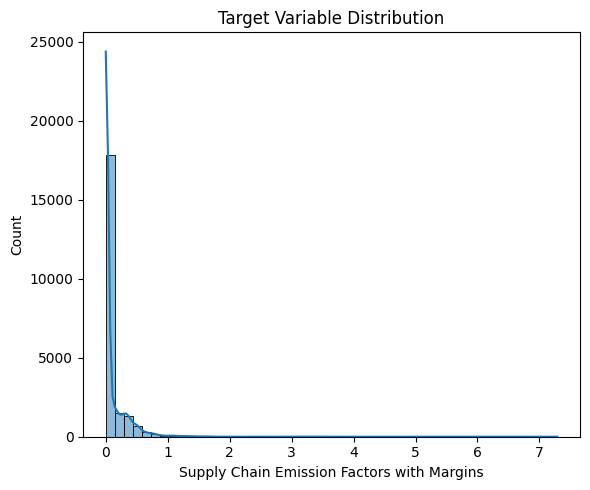

C:\Users\thaku\AppData\Local\Temp\ipykernel_15096\324814214.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


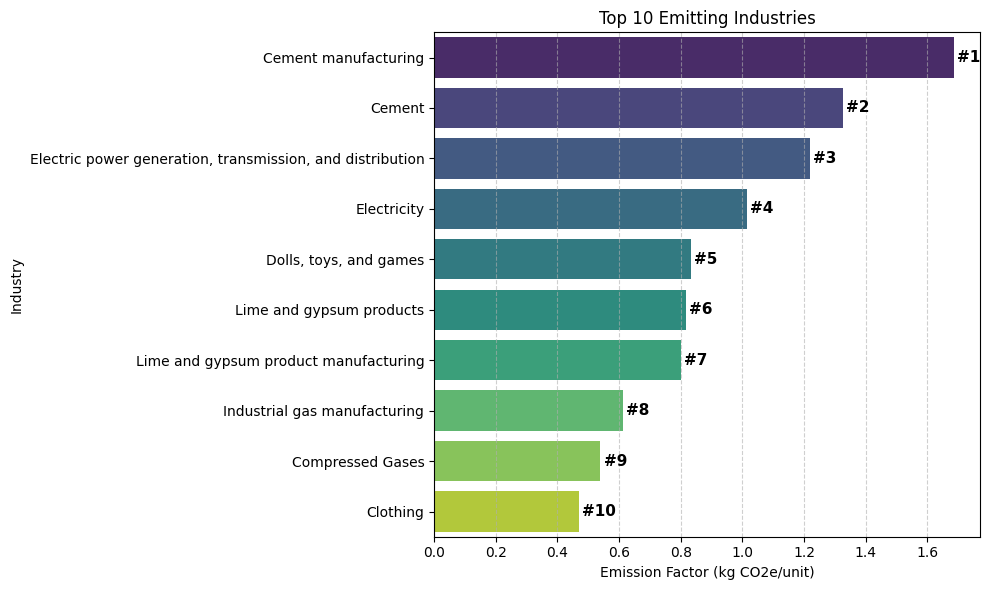

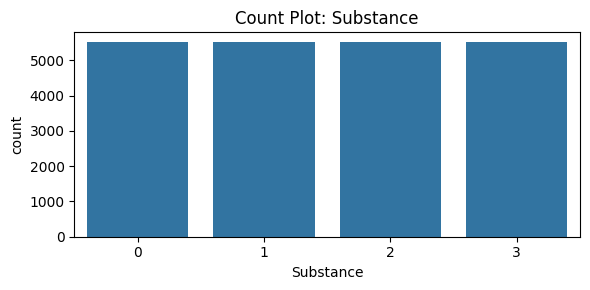

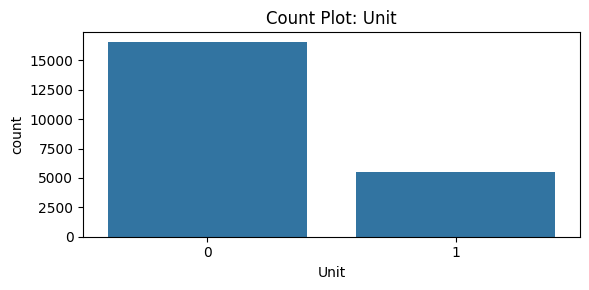

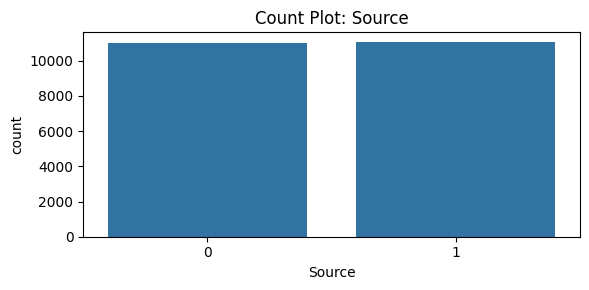

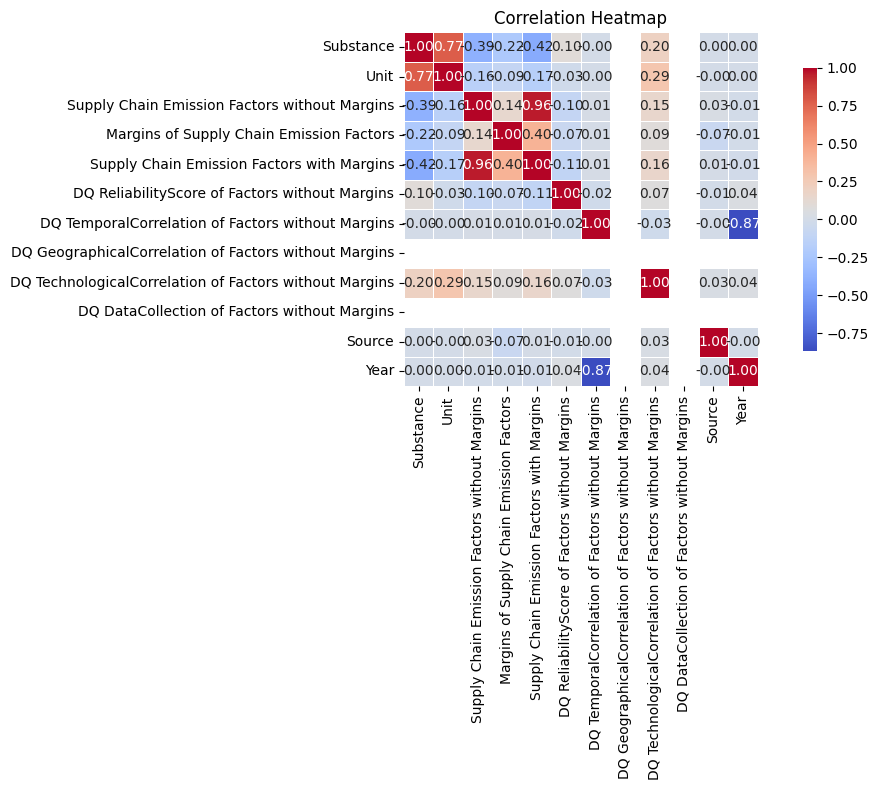

In [18]:
print("\n Dataset Info:")
print(df.info())
print("\n Null Values:")
print(df.isnull().sum())
print("\n Summary Stats:")
print(df.describe().T)

# Target Distribution Plot
plt.figure(figsize=(6, 5))
sns.histplot(df['Supply Chain Emission Factors with Margins'], bins=50, kde=True)
plt.title('Target Variable Distribution')
plt.tight_layout()
plt.savefig("plots/target_distribution.png")
plt.show()

# Top 10 Emitting Industries
top_emitters = df[['Name', 'Supply Chain Emission Factors with Margins']] \
    .groupby('Name') \
    .mean() \
    .sort_values('Supply Chain Emission Factors with Margins', ascending=False) \
    .head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Supply Chain Emission Factors with Margins',
    y='Name',
    data=top_emitters,
    palette='viridis'
)
for i, (value, _) in enumerate(zip(top_emitters['Supply Chain Emission Factors with Margins'], top_emitters['Name']), start=1):
    plt.text(value + 0.01, i - 1, f'#{i}', va='center', fontsize=11, fontweight='bold', color='black')
plt.title('Top 10 Emitting Industries')
plt.xlabel('Emission Factor (kg CO2e/unit)')
plt.ylabel('Industry')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plots/top_10_emitting_industries.png")
plt.show()

# Countplots
for col in ['Substance', 'Unit', 'Source']:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot: {col}")
    plt.tight_layout()
    plt.savefig(f"plots/{col.lower()}_countplot.png")
    plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png")
plt.show()

# Drop Unused Columns
Drop columns not needed for modeling such as 'Name', 'Code', and 'Year'.

In [19]:
# Drop unused columns
df.drop(columns=['Name', 'Code', 'Year'], inplace=True)

# Feature Scaling
Normalize features using StandardScaler.

In [20]:
# Features and target
X = df.drop(columns=['Supply Chain Emission Factors with Margins'])
y = df['Supply Chain Emission Factors with Margins']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n Features normalized.")


 Features normalized.


# Train/Test Split
Split the data into training and testing sets.

In [21]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(" Train/Test Split Done:", X_train.shape, X_test.shape)

 Train/Test Split Done: (17673, 10) (4419, 10)


# Train Random Forest Model
Train a Random Forest Regressor on the training data and evaluate its performance.

In [22]:
# Model 1: Random Forest
RF_model = RandomForestRegressor(random_state=42)
RF_model.fit(X_train, y_train)
RF_y_pred = RF_model.predict(X_test)
RF_mse = mean_squared_error(y_test, RF_y_pred)
RF_rmse = np.sqrt(RF_mse)
RF_r2 = r2_score(y_test, RF_y_pred)

# Train Linear Regression Model
Train a Linear Regression model on the training data and evaluate its performance.

In [23]:
# Model 2: Linear Regression
LR_model = LinearRegression()
LR_model.fit(X_train, y_train)
LR_y_pred = LR_model.predict(X_test)
LR_mse = mean_squared_error(y_test, LR_y_pred)
LR_rmse = np.sqrt(LR_mse)
LR_r2 = r2_score(y_test, LR_y_pred)

# Model Evaluation and Comparison
Compare model metrics (MSE, RMSE, R2) for both models and display results.

In [24]:
# Model Comparison
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'MSE': [RF_mse, LR_mse],
    'RMSE': [RF_rmse, LR_rmse],
    'R2': [RF_r2, LR_r2]
})
print("\n Model Comparison:")
print(comparison_df)


 Model Comparison:
               Model           MSE      RMSE        R2
0      Random Forest  3.774615e-05  0.006144  0.999328
1  Linear Regression  7.881378e-08  0.000281  0.999999


# Save Best Model and Scaler
Save the best performing model and the scaler using joblib.

In [25]:
# Save the Best Model (Linear Regression assumed best)
joblib.dump(LR_model, 'models/LR_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("\n Linear Regression model & scaler saved successfully!")


 Linear Regression model & scaler saved successfully!
